In [8]:
import pandas as pd
import numpy as np
import string
from wordcloud import STOPWORDS
from nltk import word_tokenize
from nltk import WordNetLemmatizer
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preparation

Loading in files

    Each line from the files will be appended to 1 list

    Preparing the strings for a DataFrame
        
        Extrapolating the score from each string ensuring a 1 or 0 is the score
        
        Putting all Strings in Lowercase

        Compiling all Reviews and their Sentiment Scores into a Dataframe
        
 Preparing the Strings for Modeling
    
    Tokenizing strings
    
    Understanding the dataset
    
        Words
            Average word length and the vocabulary of the corpus before and after
            removing stop words and lemmatization.
            
            Identifying non-english characters in the corpus
            
        Sequences
            Average Sequence length, Max Sequence length and distribution
            of sequence lengths
        
    Create an Index for the tokens
    
        Create a list of unique words that build up the cleaned corpus
        
        Apply index values +1 of each word in the vocab list to the model data,
        at this point tokens should be numbers. There will not be a 0 token from
        the indexing the 0 will be left as a placeholder to pad sequences
        
        Pad sequences with 0 to have a length of max(sequence_length) across
        all sequences
        
        
        

In [9]:
#Reading in the file of sentences
file_1 = r"-"

file_2 = r"-"

file_3 = r"-"

list_strings = []
#Reading in the text files I downloaded from the Project site
for temp_file in [file_1,file_2,file_3]:
    with open(temp_file,'r') as file:
        list_strings.append(file.readlines())
        file.close

In [10]:
platforms = ['Amazon','Yelp','Imdb']
list_strings[0][0]

'So there is no way for me to plug it in here in the US unless I go by a converter.\t0\n'

In [11]:
def get_sentiment_scores(list_of_strings):
    """
    Input: list of strings with the format of '.\tscore\n'
    
        score is a 1 digit number, in this case it is a 1 or 0, if someone 
        else uses this code with different standards you must remove the assert statement 
        and it should run fine again
        
    Output: Dataframe with 2 columns
    
        Sentiment: contains the review of the author.
        
        Score: the sentiment score 1 or 0, 1 being positive sentiment and 0 being negative.
    """
    
    sentiments = {
    "Sentiment" : [],
    "Score" : []
    }
    # Iterating through the list of strings
    for string in list_of_strings:
        #Getting the length of the string
        size = len(string)
        #Getting the score of the sentiment
        score = string[(size-2)]
        #Getting the actual sentiment
        sentence = string[0:size-4]

        #Ensuring there was no error in finding the score
        temp = int(score)
        assert (temp == 0) | (temp == 1)

        #Adding the sentiment and score to the lists to then put into a dictionary
        sentiments['Sentiment'].append(sentence.lower())
        sentiments['Score'].append(temp)
        
    return pd.DataFrame(sentiments)

#Getting the first platforms sentiments situated into a dataframe so I can concatenate in the next steps
sentiments = get_sentiment_scores(list_strings[0])
sentiments['Platform'] = 'Amazon'

#Concatenating the other transformed platform sentiments to the sentiments df
for ind in [1,2]:
    temp = get_sentiment_scores(list_strings[ind])
    temp['Platform'] = platforms[ind]
    sentiments = pd.concat([sentiments,temp]).reset_index(drop = True)

In [12]:
sentiments

,Sentiment,Score,Platform
0,so there is no way for me to plug it in here i...,0,Amazon
1,"good case, excellent value",1,Amazon
2,great for the jawbone,1,Amazon
3,tied to charger for conversations lasting more...,0,Amazon
4,the mic is great,1,Amazon
...,...,...,...
2995,i just got bored watching jessice lange take h...,0,Imdb
2996,"unfortunately, any virtue in this film's produ...",0,Imdb
2997,"in a word, it is embarrassing.",0,Imdb
2998,exceptionally bad!,0,Imdb


# Understanding the Dataset

In [13]:
sentiments.groupby(by = ['Platform'])['Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Platform,,,,,,,,
Amazon,1000.0,0.5,0.50025,0.0,0.0,0.5,1.0,1.0
Imdb,1000.0,0.5,0.50025,0.0,0.0,0.5,1.0,1.0
Yelp,1000.0,0.5,0.50025,0.0,0.0,0.5,1.0,1.0


In [14]:
string_len = []
word_lengths = []
words = []
chars = []
count_non_english = 0
for i in sentiments['Sentiment']:
    string_len.append(len(i.split()))
    for word in i.split():
        if (word.isascii()) and not(word in string.punctuation):
            words.append(word)
            word_lengths.append(len(word))
        for char in word:
            if not char.isascii():
                chars.append(char)
                count_non_english +=1
sentiments['String_len'] = string_len

In [15]:
sentiments.groupby(by = ['Score'])['Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Score,,,,,,,,
0,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1500.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [16]:
s_arr = np.array(string_len)
print(f"Average Review Length: {round(np.mean(s_arr))}")
print(f"Median Review Length: {round(np.median(s_arr))}")
print(f"Shortest Review Length: {np.min(s_arr)}")
print(f"Longest Review Length: {np.max(s_arr)}")

print(f"Size of vocabulary: {len(set(words))}")
print(f"Number of non-english characters in reviews: {len(chars)}")

Average Review Length: 12
Median Review Length: 10
Shortest Review Length: 1
Longest Review Length: 71
Size of vocabulary: 6836
Number of non-english characters in reviews: 34


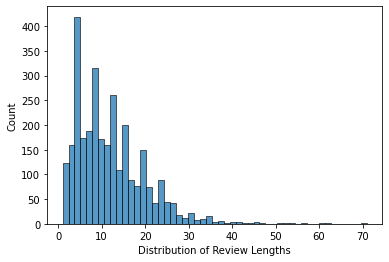

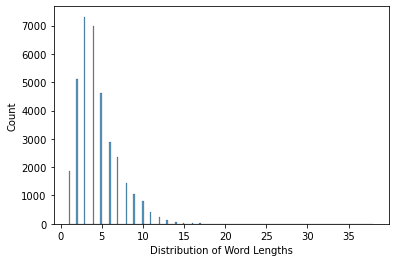

Average Word Length: 5
Median Word Length: 4
Shortest Word Length: 1
Longest Word Length: 38


In [17]:
sns.histplot(data = sentiments, x = 'String_len',)
plt.xlabel('Distribution of Review Lengths')
plt.show()

sns.histplot(data = word_lengths)
plt.xlabel('Distribution of Word Lengths')
plt.show()

word_arr = np.array(word_lengths)
print(f"Average Word Length: {round(np.mean(word_arr))}")
print(f"Median Word Length: {round(np.median(word_arr))}")
print(f"Shortest Word Length: {np.min(word_arr)}")
print(f"Longest Word Length: {np.max(word_arr)}")

# Back to Data Prep

Tokenizing, removing stop words, punctuation marks within tokens and Lemmatizing strings to increase recognition of the frequency of root word occurances 

In [18]:
def remove_stopwords(df):
    '''
    Input: Dataframe with a Sentiment column
    
    Output: Dataframe with stop words removed from the sentiment column
    
    In this project I have an addtional step to remove stop words after tokenization
    and removing intermediate punctuation typos like great.work from being a string
    '''
    stopwords = set(STOPWORDS)
    df = df.copy()
    for lab,row in df.iterrows():
        sentiment = df.loc[lab,'Sentiment'].split()
        # iterating through the words in the sentiment to identify stopwords
        for word in sentiment:
            if word in stopwords:
                sentiment.remove(word)
        sentence = ""
        for word in sentiment:
            sentence = sentence + " " + word
            
        df.loc[lab,'Sentiment'] = sentence
        
    return df

clean = remove_stopwords(sentiments)
clean.head()

,Sentiment,Score,Platform,String_len
0,there no way me plug in in us unless go a con...,0,Amazon,21
1,"good case, excellent value",1,Amazon,4
2,great the jawbone,1,Amazon,4
3,tied charger conversations lasting than 45 mi...,0,Amazon,11
4,mic great,1,Amazon,4


In [19]:
word_tokens = [word_tokenize(review) for review in clean.Sentiment]

In [20]:
#Checking Punctuation Mark Typos in Tokens 
def check_tokens(list_of_list):
    #List that will replace the list_of_list
    replace = []
    for l in list_of_list:
        replace.append(check_words(l))
    #Returning the list of substituted strings
    # Stopwords have been removed in two phases now
    return replace

#Finding words and seperating them at punctuation marks
def check_words(list_strings):
    new_list = []
    #Iterating through the list to parse through string characters
    for s in list_strings:
        #Placeholder to store the string makeup leading up to a punctuation mark
        # or the end of the string
        hold_s = ''
        for char in s:
            if (char not in string.punctuation) and (char.isascii()):
                hold_s = hold_s + char
            # Preventing a "" from being in the string list
            elif hold_s != "":
                #Preventing stop words and punctuation marks from being added as tokens 
                if hold_s not in STOPWORDS and (char not in string.punctuation):
                    new_list.append(hold_s)
                
                hold_s = ''
        #Preventing blank strings and stopwords from being added to the list
        if (hold_s != '') and (hold_s not in STOPWORDS):
            new_list.append(hold_s)
    
    return new_list
                
clean_tokens = check_tokens(word_tokens)

In [21]:
#Lemmatization process
lemmatizer = WordNetLemmatizer()
#placeholder to add new sets of sequences to
keep_tokens = []
#Capturing all words that are in the lemmatized and filtered corpus vocabulary
words = []
#Getting descriptive data on words and sequences
word_lengths = []
sequence_lengths = []

#Looping through tokens
for tokens in clean_tokens:
    #Placeholder for lemmatized tokens in the sequence
    new_tokens = []
    sequence_lengths.append(len(tokens))
    #Lemmatizing the tokens and collecting information about the words
    for token in tokens:
        new = lemmatizer.lemmatize(token, pos = 'n')
        new_tokens.append(new)
        words.append(new)
        word_lengths.append(len(new))
    keep_tokens.append(new_tokens)

In [22]:
keep_tokens

[['way', 'plug', 'u', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tied', 'charger', 'conversation', 'lasting', '45', 'major', 'problem'],
 ['mic', 'great'],
 ['jiggle', 'plug', 'line', 'right', 'decent', 'volume'],
 ['several',
  'dozen',
  'several',
  'hundred',
  'contact',
  'imagine',
  'fun',
  'sending',
  'one',
  'one'],
 ['razr', 'owner', 'must'],
 ['needle', 'say', 'wasted', 'money'],
 ['waste', 'money', 'time'],
 ['sound', 'quality', 'great'],
 ['impressed', 'going', 'original', 'battery', 'extended', 'battery'],
 ['two',
  'seperated',
  'mere',
  'ft',
  'started',
  'notice',
  'excessive',
  'static',
  'garbled',
  'sound',
  'headset'],
 ['good', 'quality', 'thoug'],
 ['design', 'odd', 'ear', 'clip', 'comfortable'],
 ['highly', 'recommend', 'one', 'blue', 'tooth', 'phone'],
 ['advise', 'everyone', 'fooled'],
 ['far', 'good'],
 ['work', 'great'],
 ['click', 'place', 'way', 'make', 'wonder', 'long', 'mechanism', 'last

# Understanding the Clean Dataset

Now that I have removed the bloat words from reviews we can get an accurate view into the makeup of our tokens that will be fed into the model

In [23]:
seq_len = np.array(sequence_lengths)
w_len = np.array(word_lengths)
u_w_len = np.array([len(x) for x in set(words)])
print("Average Sequence Length",round(np.mean(seq_len)))
print("Median Sequence Length",round(np.median(seq_len)))
print("Max Sequence Length",round(np.max(seq_len)))
print("Average Word Length of the Corpus",round(np.mean(w_len)))
print("Median Word Length of the Corpus",round(np.median(w_len)))
print("Size of Vocabulary",len(set(words)))
print("Average Word Length of Vocabulary",round(np.mean(u_w_len)))
print("Median Word Length of Vocabulary",round(np.median(u_w_len)))
print('Largest word length',np.max(u_w_len))

Average Sequence Length 6
Median Sequence Length 5
Max Sequence Length 42
Average Word Length of the Corpus 6
Median Word Length of the Corpus 5
Size of Vocabulary 4623
Average Word Length of Vocabulary 7
Median Word Length of Vocabulary 6
Largest word length 17


In [24]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

# Last Data Preparation Step

Creating word index list to substitute words for numbers, so we can use our sequences in the SNN. After transforming the words to numbers I will pad the sequences with 0s to match the length of the longest sequence. 

In [25]:
#Padding each sequence so the number of tokens in each sequence aligns across all rows
for tokens in keep_tokens:
    while len(tokens) < np.max(seq_len):
        tokens.insert(0,0)

#Creating an index vocabulary and transforming words to numbers
# Adding 1 to vocab_size because we are padding with 
vocab_size = len(set(words)) + 1
vocabulary = list(set(words))

ind = []
for seq in keep_tokens:
    temp_seq = []
    for token in seq:
        if token != 0:
            # Adding 1 to the index because we want 0s as the pad value
            temp_seq.append(vocabulary.index(token)+1)
        else:
            temp_seq.append(0)
    ind.append(temp_seq)

#Creating Df for the model and adding some reference information for user
clean_tokens = {
    "tokens" : keep_tokens,
    "token_len":sequence_lengths,
    "score": clean.Score,
    "encoded_tokens" : ind
}
model_tokens = pd.DataFrame(clean_tokens)

In [27]:
model_tokens

,tokens,token_len,score,encoded_tokens
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",7,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
2995,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",7,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2996,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",9,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2997,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2998,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",2,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# Modeling

Train test split seperates the training data from the test data randomly, stratified by the response variable so the proportion of positive and negative sentiment is equal in the test and training set

to_categorical allows the Neural Network to correctly read the score variable

In [28]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

In [29]:
# Seperating X from y for the modeling process
X = model_tokens['encoded_tokens']
y = to_categorical(model_tokens['score'])
# Making an np array of np arrays so each sentence is sturctured in an array of its 
# words so the model can read an array
X = np.array([np.array(val).T for val in X])
# Performing the train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size = .3,
                                                    stratify = y,
                                                    random_state = 1000)

In [30]:
X

array([[   0,    0,    0, ..., 3974, 2928,  133],
       [   0,    0,    0, ...,  774, 3803, 2386],
       [   0,    0,    0, ...,    0, 1919, 2404],
       ...,
       [   0,    0,    0, ...,    0, 2076, 4573],
       [   0,    0,    0, ...,    0, 2175,  216],
       [   0,    0,    0, ...,  171, 4198,  798]])

In [31]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import GlobalMaxPooling1D,SpatialDropout1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import LSTM, Bidirectional

In [32]:
vocab_size

4624

In [65]:
# Best Model weights will be saved after each test, so brute forcing an optimal model is possible
weights_path = "-"
# Define early_stopping_monitor
early_stopping_monitor = EarlyStopping(patience=6)
#checkpoint = ModelCheckpoint(filepath = weights_path,
#                             monitor = 'val_accuracy',
#                             save_best_only = True,
#                             save_weights_only = True)
#callbacks = [early_stopping_monitor,checkpoint]

#Initiate the Sequential Model
model = Sequential()
# Generate an embedding layer to map closely associated words together
# Enables the model to deal with the complexity of language in a high dimensional space
model.add(Embedding(vocab_size,50,trainable = True))
# Dropout enables some management for overfitting where learned patterns are forgotten at random
model.add(SpatialDropout1D(.3))
# Bidirectional layer so words can be understood in context
model.add(Bidirectional(LSTM(150,
                             dropout = .2,
                             recurrent_dropout = .2,
                             return_sequences = True,
                            activation = 'sigmoid')))
model.add(Bidirectional(LSTM(50,
                             dropout = .2,
                             recurrent_dropout = .2,
                             return_sequences = True,
                            activation = 'sigmoid')))
# Pools output of Bidirectional layers into a single dimension 
model.add(GlobalMaxPooling1D())
# One more computational layer to aid learning
model.add(Dense(25,activation = 'relu'))
# Prediction Layer
model.add(Dense(2, activation = 'softmax'))

In [66]:
model.compile(loss = 'binary_crossentropy', 
              optimizer = 'adam',
             metrics = ['accuracy'])

In [67]:
results = model.fit(X_train,y_train,
                    epochs = 20, batch_size = 50,
                    validation_split = .2,)
                #Commented out because I don't want to lose the best model weights
                   #callbacks = callbacks)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 254ms/step - accuracy: 0.4832 - loss: 0.7070 - val_accuracy: 0.4571 - val_loss: 0.6957
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.5008 - loss: 0.6934 - val_accuracy: 0.4571 - val_loss: 0.6957
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.5150 - loss: 0.6937 - val_accuracy: 0.4571 - val_loss: 0.7041
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.5223 - loss: 0.6922 - val_accuracy: 0.4571 - val_loss: 0.7031
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.5241 - loss: 0.6878 - val_accuracy: 0.6524 - val_loss: 0.6753
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.7266 - loss: 0.6493 - val_accuracy: 0.7762 - val_loss: 0.5712
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.8996 - loss: 0.4441 - val_accuracy: 0.7762 - val_loss: 0.4496
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9113 - loss: 0.2470 - val_accuracy: 0

In [48]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 42, 50)         │       231,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 42, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 42, 300)        │       241,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 42, 100)        │       140,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 100)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            52 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,846,133 (7.04 MB)

 Trainable params: 615,377 (2.35 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,230,756 (4.69 MB)

In [68]:
#Applying best model weights to the model
model.load_weights(filepath = weights_path)

In [69]:
# Using the best model weights for testing on the test set
preds = model.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


In [70]:
#Getting the most likely prediction value and the test prediction values in a list
actuals = [list(prediction).index(max(list(prediction))) for prediction in preds]
test_actuals = [list(y).index(max(list(y))) for y in y_test]

In [71]:
correct = 0
for i in range(len(test_actuals)):
    if test_actuals[i] == actuals[i]:
        correct += 1
print('Accuracy')
print(correct/len(test_actuals))

Accuracy
0.7855555555555556


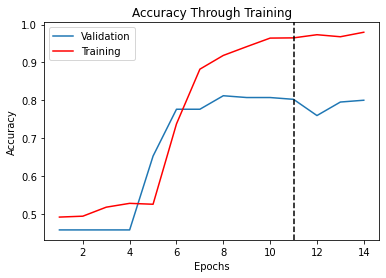

In [72]:
#Making a line plot of accuracy scores in different epochs
sns.lineplot(x = range(1,len(results.history['val_loss'])+1),
             y = results.history['val_accuracy'],label = 'Validation')
sns.lineplot(x = range(1,len(results.history['val_loss'])+1)
             ,y = results.history['accuracy'],label = 'Training',color = 'red')
plt.title('Accuracy Through Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.axvline(11,color = 'black',linestyle='--')
plt.show()

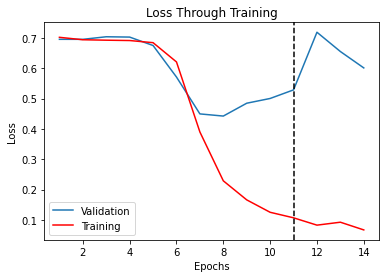

In [73]:
#Plotting the loss function value across the training epochs
sns.lineplot(x = range(1,len(results.history['val_loss'])+1),
             y = results.history['val_loss'],label = 'Validation')
sns.lineplot(x = range(1,len(results.history['val_loss'])+1),
             y = results.history['loss'],label = 'Training',color = 'red')
plt.title('Loss Through Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.axvline(11,color = 'black',linestyle='--')
plt.show()

In [79]:
prepared_data = model_tokens[['encoded_tokens','score']]
prepared_data.to_csv("-")